In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sys.path.insert(0, '..')
from sim.env import DiffDriveEnv
from sim.expert import ExpertController

In [ ]:
N = 10000
MAX_STEPS = 1000

env = DiffDriveEnv()
expert = ExpertController(noise_std=0.001)

trajectories = []  # list of dicts

for ep in range(N):
    obs = env.reset()
    xs, ys, thetas = [], [], []
    done = False
    for _ in range(MAX_STEPS):
        state = env.get_state()
        xs.append(state[0])
        ys.append(state[1])
        thetas.append(np.arctan2(state[3], state[2]))
        action = expert.act(obs, state)
        obs, done = env.step(action)
        if done:
            state = env.get_state()
            xs.append(state[0]); ys.append(state[1])
            thetas.append(np.arctan2(state[3], state[2]))
            break
    trajectories.append({
        'ep': ep, 'xs': np.array(xs), 'ys': np.array(ys), 'thetas': np.array(thetas),
        'done': done, 'steps': len(xs),
        'x0': xs[0], 'y0': ys[0], 'theta0': thetas[0],
        'xf': xs[-1], 'yf': ys[-1], 'thetaf': thetas[-1],
    })

success = sum(1 for t in trajectories if t['done'])
print(f'Success: {success}/{N}')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = cm.tab20(np.linspace(0, 1, N))

for t in trajectories:
    xs, ys, thetas = t['xs'], t['ys'], t['thetas']
    if t['done']:
        color = colors[t['ep']]
        lw, alpha, zorder = 1.2, 0.6, 1
    else:
        color = 'red'
        lw, alpha, zorder = 2.2, 0.95, 3

    ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

    dx = np.cos(thetas[0]) * 0.18
    dy = np.sin(thetas[0]) * 0.18
    ax.annotate('', xy=(xs[0] + dx, ys[0] + dy), xytext=(xs[0], ys[0]),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    ax.plot(xs[0], ys[0], 'o', color=color, markersize=5, zorder=zorder)

    if not t['done']:
        ax.plot(xs[-1], ys[-1], 'x', color='red', markersize=11, markeredgewidth=2.5, zorder=4)
        ax.text(xs[0] + 0.12, ys[0] + 0.12, f"#{t['ep']}", color='red', fontsize=8, fontweight='bold', zorder=4)

ax.plot(0, 0, 'k*', markersize=18, zorder=5)
ax.add_patch(plt.Circle((0, 0), 0.05, color='black', fill=False, linestyle='--', linewidth=1))

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title(f'Expert trajectories — {success}/{N} success\n'
             f'● start  → heading  ★ goal  ✕ failed (red)', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/trajectories_expert.png', dpi=120)
plt.show()


(array([  3.,   4.,   4.,   8.,  16.,  28.,  45.,  79., 121., 170., 231.,
        287., 336., 456., 452., 563., 657., 660., 759., 701., 713., 554.,
        515., 364., 324., 219., 187., 171., 156., 150., 161., 131., 131.,
        130., 100.,  89.,  59.,  69.,  50.,  52.,  36.,  25.,   8.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  7.  ,  15.53,  24.06,  32.59,  41.12,  49.65,  58.18,  66.71,
         75.24,  83.77,  92.3 , 100.83, 109.36, 117.89, 126.42, 134.95,
        143.48, 152.01, 160.54, 169.07, 177.6 , 186.13, 194.66, 203.19,
        211.72, 220.25, 228.78, 237.31, 245.84, 254.37, 262.9 , 271.43,
        279.96, 288.49, 297.02

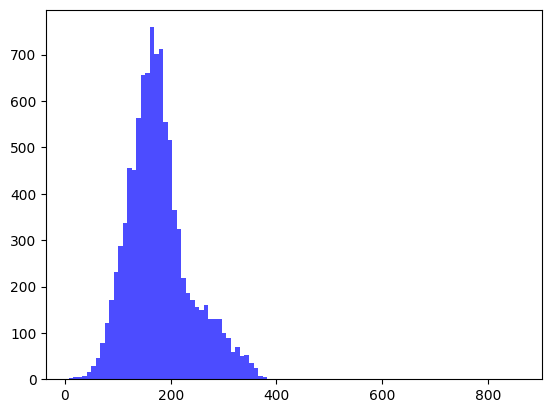

In [4]:
steps = np.array([i['steps'] for i in trajectories if i['done']])
plt.hist(steps, bins=100, color='blue', alpha=0.7)

In [5]:
failed = [t for t in trajectories if not t['done']]

if not failed:
    print("All episodes succeeded.")
else:
    print(f"Failed episodes ({len(failed)}):\n")
    print(f"{'ep':>4}  {'x0':>7}  {'y0':>7}  {'θ0':>7}  {'xf':>7}  {'yf':>7}  {'θf':>7}  {'steps':>6}  {'dist_f':>8}")
    print("-" * 72)
    for t in failed:
        dist_f = np.sqrt(t['xf']**2 + t['yf']**2)
        print(f"{t['ep']:>4}  {t['x0']:>7.3f}  {t['y0']:>7.3f}  {t['theta0']:>7.3f}"
              f"  {t['xf']:>7.3f}  {t['yf']:>7.3f}  {t['thetaf']:>7.3f}  {t['steps']:>6}  {dist_f:>8.4f}")


Failed episodes (19):

  ep       x0       y0       θ0       xf       yf       θf   steps    dist_f
------------------------------------------------------------------------
  57   -1.573    2.814    0.599    0.011    0.010   -0.833    1000    0.0150
 933    0.926   -2.516   -1.602   -0.006    0.014    0.369    1000    0.0150
2590    0.101   -2.811    1.176   -0.014    0.004   -1.832    1000    0.0150
3255    2.716   -1.178    2.126    0.012   -0.009    0.970    1000    0.0150
3268   -2.984    1.186    3.051   -0.008   -0.012    2.502    1000    0.0150
3674   -0.761   -2.642    1.567   -0.014   -0.006    2.002    1000    0.0150
4663    1.079    2.694   -1.327   -0.014    0.006    1.077    1000    0.0150
4775    1.299   -2.339   -0.808    0.012    0.009    2.126    1000    0.0150
5164    1.741   -2.658    3.103   -0.011    0.010    0.812    1000    0.0150
5278    1.230    2.765    0.845   -0.008    0.013    0.536    1000    0.0150
5427   -2.384   -1.890   -0.019    0.014    0.007    2.02

dict_keys(['ep', 'xs', 'ys', 'thetas', 'done', 'steps', 'x0', 'y0', 'theta0', 'xf', 'yf', 'thetaf'])


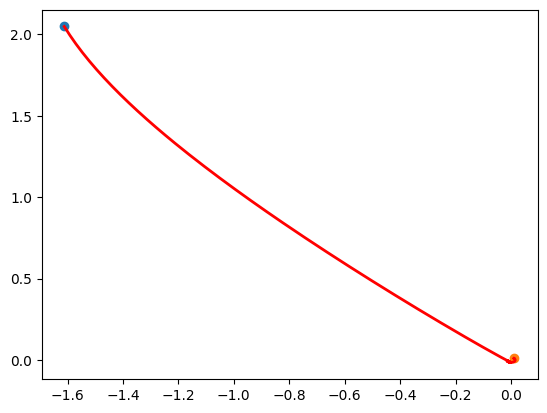

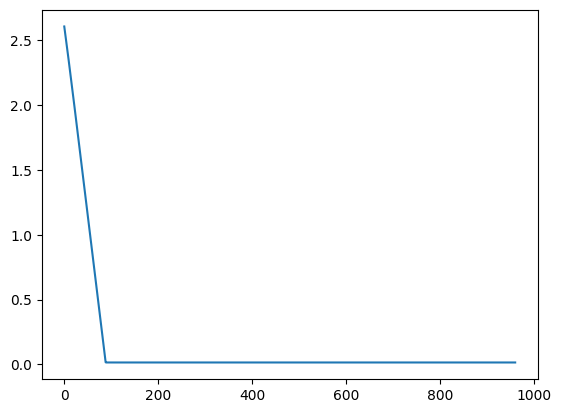

[ 1.92225804  1.93775301  1.95267315  1.96704003  1.9808746   1.99419715
  2.00702733  2.01938416  2.03128601  2.04275064  2.05379516  2.06443612
  2.07468943  2.08457046  2.09409399  2.10327425  2.11212497  2.12065931
  2.12888998  2.13682918  2.14448863  2.15187962  2.159013    2.1658992
  2.17254823  2.17896972  2.18517294  2.19116678  2.1969598   2.20256022
  2.20797593  2.21321455  2.21828337  2.22318942  2.22793947  2.23254002
  2.23699733  2.24131744  2.24550614  2.24956903  2.25351152  2.25733881
  2.26105591  2.2646677   2.26817885  2.27159391  2.27491729  2.27815323
  2.2813059   2.28437932  2.28737742  2.29030402  2.29316288  2.29595766
  2.29869199  2.30136943  2.30399349  2.30656768  2.30909548  2.31158041
  2.31402597  2.31643574  2.31881336  2.32116257  2.32348722  2.32579137
  2.32807924  2.33035536  2.33262457  2.33489213  2.33716382  2.33944607
  2.34174613  2.34407225  2.34643405  2.34884284  2.35131215  2.35385853
  2.35650262  2.35927072  2.36219731  2.36532898  2.

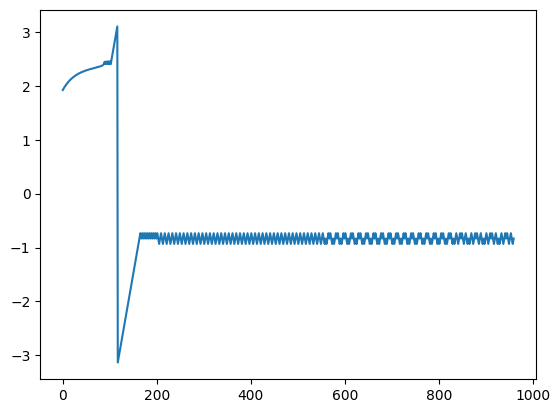

In [6]:
print(failed[0].keys())

st = 40
fn = 1000

plt.plot(failed[0]['xs'][st], failed[0]['ys'][st], 'o')
plt.plot(failed[0]['xs'][fn-1], failed[0]['ys'][fn-1], 'o')
plt.plot(failed[0]['xs'][st:fn], failed[0]['ys'][st:fn], 'r-', linewidth=2)
plt.show()
plt.plot(np.linalg.norm(np.array([failed[0]['xs'][st:fn], failed[0]['ys'][st:fn]]), axis=0))
plt.show()
plt.plot(failed[0]['thetas'][st:fn])

print(failed[0]['thetas'][st:fn])
print(failed[0]['xs'][st:fn])
print(failed[0]['ys'][st:fn])

In [ ]:
N = 15
MAX_STEPS = 1000
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

env    = DiffDriveEnv()
expert = ExpertController(noise_std=0.001)

trajectories = []

for i, angle in enumerate(angles):
    env.x         = 0.0
    env.y         = -3.0
    env.cos_theta = np.cos(angle)
    env.sin_theta = np.sin(angle)
    obs = env._get_obs()

    xs, ys, thetas = [], [], []
    done = False

    for _ in range(MAX_STEPS):
        state = env.get_state()
        xs.append(state[0])
        ys.append(state[1])
        thetas.append(np.arctan2(state[3], state[2]))

        action = expert.act(obs, state)
        obs, done = env.step(action)
        if done:
            state = env.get_state()
            xs.append(state[0]); ys.append(state[1])
            thetas.append(np.arctan2(state[3], state[2]))
            break

    trajectories.append({
        'ep': i, 'xs': np.array(xs), 'ys': np.array(ys), 'thetas': np.array(thetas),
        'done': done, 'steps': len(xs),
        'x0': xs[0], 'y0': ys[0], 'theta0': thetas[0],
        'xf': xs[-1], 'yf': ys[-1], 'thetaf': thetas[-1],
    })

success = sum(1 for t in trajectories if t['done'])
print(f'Success: {success}/{N}')

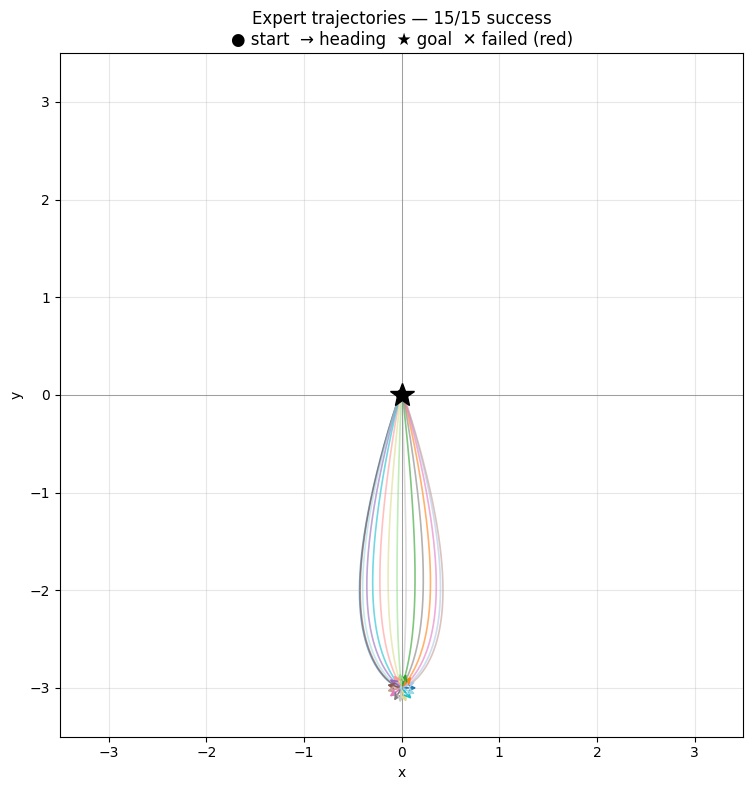

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = cm.tab20(np.linspace(0, 1, N))

for t in trajectories:
    xs, ys, thetas = t['xs'], t['ys'], t['thetas']
    if t['done']:
        color = colors[t['ep']]
        lw, alpha, zorder = 1.2, 0.6, 1
    else:
        color = 'red'
        lw, alpha, zorder = 2.2, 0.95, 3

    ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

    dx = np.cos(thetas[0]) * 0.18
    dy = np.sin(thetas[0]) * 0.18
    ax.annotate('', xy=(xs[0] + dx, ys[0] + dy), xytext=(xs[0], ys[0]),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    ax.plot(xs[0], ys[0], 'o', color=color, markersize=5, zorder=zorder)

    if not t['done']:
        ax.plot(xs[-1], ys[-1], 'x', color='red', markersize=11, markeredgewidth=2.5, zorder=4)
        ax.text(xs[0] + 0.12, ys[0] + 0.12, f"#{t['ep']}", color='red', fontsize=8, fontweight='bold', zorder=4)

ax.plot(0, 0, 'k*', markersize=18, zorder=5)
ax.add_patch(plt.Circle((0, 0), 0.05, color='black', fill=False, linestyle='--', linewidth=1))

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title(f'Expert trajectories — {success}/{N} success\n'
             f'● start  → heading  ★ goal  ✕ failed (red)', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('../trajectories_expert.png', dpi=120)
plt.show()


Failed: 1/15


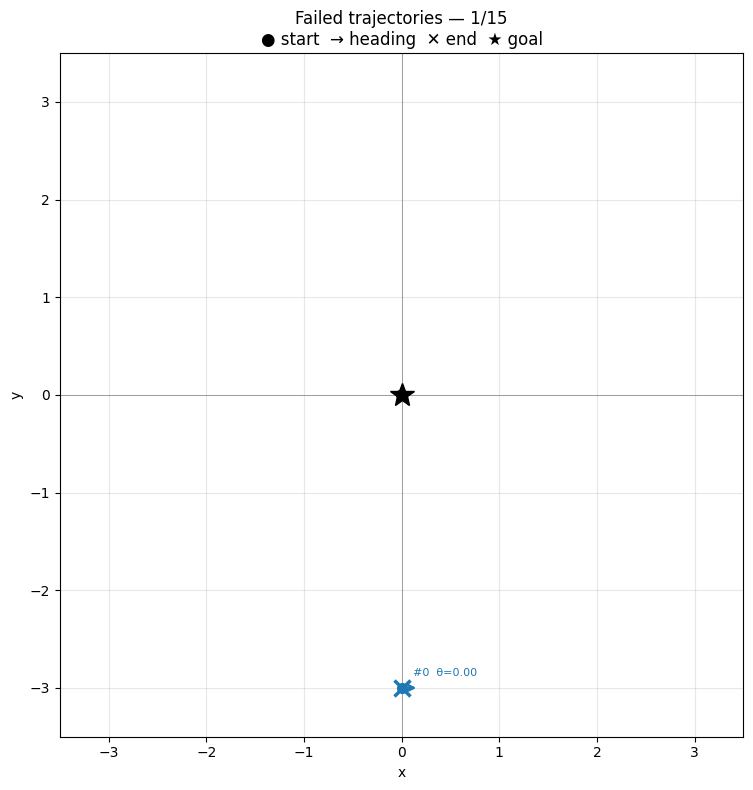

In [11]:
failed = [t for t in trajectories if not t['done']]
print(f'Failed: {len(failed)}/{N}')

if not failed:
    print("All succeeded — nothing to show.")
else:
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = cm.tab10(np.linspace(0, 1, len(failed)))

    for color, t in zip(colors, failed):
        xs, ys, thetas = t['xs'], t['ys'], t['thetas']
        ax.plot(xs, ys, color=color, linewidth=1.8, alpha=0.9)

        dx = np.cos(thetas[0]) * 0.18
        dy = np.sin(thetas[0]) * 0.18
        ax.annotate('', xy=(xs[0] + dx, ys[0] + dy), xytext=(xs[0], ys[0]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=7, zorder=3)
        ax.plot(xs[-1], ys[-1], 'x', color=color, markersize=11, markeredgewidth=2.5, zorder=4)
        ax.text(xs[0] + 0.12, ys[0] + 0.12,
                f"#{t['ep']}  θ={t['theta0']:.2f}", color=color, fontsize=8)

    ax.plot(0, 0, 'k*', markersize=18, zorder=5)
    ax.add_patch(plt.Circle((0, 0), 0.05, color='black', fill=False, linestyle='--', linewidth=1))

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(f'Failed trajectories — {len(failed)}/{N}\n● start  → heading  ✕ end  ★ goal', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()